In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import scipy.stats as stats
import nibabel as nib
from nilearn import plotting
from rsatoolbox.inference import eval_fixed
from rsatoolbox.model import ModelFixed
from rsatoolbox.util.searchlight import get_volume_searchlight, get_searchlight_RDMs, evaluate_models_searchlight
from statsmodels.stats.multitest import fdrcorrection
from nilearn.image import new_img_like
import nilearn.image as nlimg
import seaborn as sns
from sklearn.metrics import pairwise_distances
from scipy.stats import pearsonr
from nilearn.image import resample_img

In [51]:
def upper_tri(RDM):
    """upper_
     returns the upper triangular index of an RDM

    Args:
        RDM 2Darray: squareform RDM

    Returns:
        1D array: upper triangular vector of the RDM
    """
    # returns the upper triangle
    m = RDM.shape[0]
    r, c = np.triu_indices(m, 1)
    return RDM[r, c]

# Smoothing function: Moving average
def smooth(data, window_size=50):
    return np.convolve(data, np.ones(window_size) / window_size, mode='same')


def find_significant_clusters(data, baseline_mean, baseline_std, min_consecutive=4):
    # Calculate threshold as 5 standard deviations above baseline mean
    threshold = baseline_mean + 2 * baseline_std
    
    # Find points exceeding threshold AND positive correlation

    significant_points = (data > threshold) & (data > 0)
    
    # Find clusters of consecutive significant points
    significant_clusters = []
    count = 0
    start_idx = None
    
    for i in range(len(significant_points)):
        if significant_points[i]:
            if start_idx is None:
                start_idx = i
            count += 1
        else:
            if count >= min_consecutive:
                significant_clusters.extend(range(start_idx, start_idx + count))
            count = 0
            start_idx = None
            
    # Check for significant cluster at the end
    if count >= min_consecutive:
        significant_clusters.extend(range(start_idx, start_idx + count))
        
    return np.array(significant_clusters, dtype=int)

# # Function to extract masked data and compute RDM
# def compute_rdm(brain_data, mask, mask_name):
#     """
#     Compute the RDM for masked voxel data across stimuli.

#     Parameters:
#         brain_data (numpy array): Shape (20, 60, 53, 63, 46), brain data per subject.
#         mask (numpy array): Binary mask of shape (53, 63, 46).
#         mask_name (str): Name of the mask (for logging).

#     Returns:
#         rdms (numpy array): RDM of shape (20, 60, 60) for all subjects.
#     """
#     n_subjects, n_stimuli = brain_data.shape[:2]
#     rdms = np.zeros((n_subjects, n_stimuli, n_stimuli))

#     # Flatten the mask to 1D
#     mask_flat = mask.ravel()  # Shape: (153594,)
#     total_voxels_in_mask = np.sum(mask_flat)  # Total voxels selected by mask

#     # Reshape brain data to (20, 60, num_voxels)
#     brain_data_flat = brain_data.reshape(n_subjects, n_stimuli, -1)  # Shape: (20, 60, 153594)

#     print(f"{mask_name}: Total voxel count in mask: {total_voxels_in_mask}")

#     # Apply the mask to extract relevant voxels
#     for subj in range(n_subjects):
#         masked_data = brain_data_flat[subj][:, mask_flat > 0]  # Shape: (60, num_voxels_in_mask)

#         # Check for NaN values in the masked data
#         nan_count = np.isnan(masked_data).sum()
#         if nan_count > 0:
#             print(f"Subject {subj + 1}: Masked data contains {nan_count} NaN values. "
#                   f"Total voxel count in the mask is {total_voxels_in_mask}.")

#             # Optionally replace NaNs with 0 to proceed
#             masked_data = np.nan_to_num(masked_data)

#         # Ensure there are voxels to compute RDM
#         if masked_data.shape[1] == 0:
#             raise ValueError("Mask results in zero voxels being selected.")

#         # Compute pairwise distances (RDM)
#         rdm = pairwise_distances(masked_data, metric='correlation')  # Shape: (60, 60)
#         rdms[subj] = rdm

#     return rdms

def compute_rdm(brain_data, mask, mask_name):
    """
    Compute the RDM for masked voxel data across stimuli.

    Parameters:
        brain_data (numpy array): Shape (20, 60, 53, 63, 46), brain data per subject.
        mask (numpy array): Binary mask of shape (53, 63, 46).
        mask_name (str): Name of the mask (for logging).

    Returns:
        rdms (numpy array): RDM of shape (20, 60, 60) for all subjects.
    """
    from sklearn.metrics import pairwise_distances  # Ensure this is imported

    n_subjects, n_stimuli = brain_data.shape[:2]
    rdms = np.zeros((n_subjects, n_stimuli, n_stimuli))

    # Flatten the mask to 1D
    mask_flat = mask.ravel()  # Shape: (153594,)
    total_voxels_in_mask = np.sum(mask_flat)  # Total voxels selected by mask

    # Reshape brain data to (20, 60, num_voxels)
    brain_data_flat = brain_data.reshape(n_subjects, n_stimuli, -1)  # Shape: (20, 60, 153594)

    print(f"{mask_name}: Total voxel count in mask: {total_voxels_in_mask}")

    # Loop over subjects to compute their RDMs
    for subj in range(n_subjects):
        # Extract only the voxels within the mask
        masked_data = brain_data_flat[subj][:, mask_flat > 0]  # Shape: (60, num_voxels_in_mask)

        # Check for NaN values in the masked data
        nan_count = np.isnan(masked_data).sum()
        if nan_count > 0:
            print(f"Subject {subj + 1}: Masked data contains {nan_count} NaN values. Total voxel count in mask: {total_voxels_in_mask}.")
            # Count valid voxels (columns where every stimulus value is not NaN)
            valid_voxels = np.sum(np.all(~np.isnan(masked_data), axis=0))
            if valid_voxels == 0:
                print(f"Subject {subj + 1}: All {masked_data.shape[1]} masked voxels are NaN.")
            else:
                print(f"Subject {subj + 1}: {valid_voxels} out of {masked_data.shape[1]} masked voxels are completely valid (non-NaN).")
            # Optionally, replace NaNs with 0 to proceed
            masked_data = np.nan_to_num(masked_data)
        else:
            valid_voxels = masked_data.shape[1]
            print(f"Subject {subj + 1}: All {valid_voxels} masked voxels are valid (non-NaN).")

        # Ensure there are voxels to compute the RDM
        if masked_data.shape[1] == 0:
            raise ValueError(f"Subject {subj + 1}: Mask results in zero voxels being selected.")

        # Compute the pairwise distances (RDM) using correlation as the metric
        rdm = pairwise_distances(masked_data, metric='correlation')  # Shape: (60, 60)
        rdms[subj] = rdm

    return rdms


# Function to compute EEG RDMs
def compute_eeg_rdms(eeg_arr, metric='correlation'):
    """
    Compute EEG RDMs based on the 31 EEG channels across stimuli and time points.

    Parameters:
        eeg_arr (numpy array): EEG data of shape (20, 31, 60, 575)
                              (subjects, channels, stimuli, time points).
        metric (str): Distance metric to use for RDM computation (e.g., 'correlation', 'euclidean').

    Returns:
        eeg_rdms (numpy array): RDMs of shape (20, 60, 60, 575)
                                (subjects, stimuli x stimuli, time points).
    """
    n_subjects, n_channels, n_stimuli, n_timepoints = eeg_arr.shape
    eeg_rdms = np.zeros((n_subjects, n_stimuli, n_stimuli, n_timepoints))

    # Iterate over subjects
    for subj in range(n_subjects):
        print(f"Processing Subject {subj + 1}/{n_subjects}...")
        
        # Iterate over time points
        for t in range(n_timepoints):
            # Extract data at time point t for all stimuli (shape: 60, 31)
            data_at_t = eeg_arr[subj, :, :, t].T  # Transpose to shape (60, 31)
            
            # Compute pairwise distances (RDM) between stimuli
            rdm = pairwise_distances(data_at_t, metric=metric)  # Shape: (60, 60)
            
            # Store the RDM
            eeg_rdms[subj, :, :, t] = rdm

    return eeg_rdms


def extract_upper_triangle(matrix):
    """Extract the upper triangular part of a matrix as a 1D array, excluding the diagonal."""
    return matrix[np.triu_indices_from(matrix, k=1)]

def correlate_rdms(brain_rdms, eeg_rdms):
    """
    Correlate brain RDMs (motor or loc) with EEG RDMs over time for each subject.

    Parameters:
        brain_rdms (numpy array): Shape (20, 60, 60), brain RDMs (motor or loc).
        eeg_rdms (numpy array): Shape (20, 60, 60, 575), EEG RDMs.

    Returns:
        correlations (numpy array): Correlations of shape (20, 575).
    """
    n_subjects, _, _, n_timepoints = eeg_rdms.shape
    correlations = np.zeros((n_subjects, n_timepoints))

    # Loop over subjects
    for subj in range(n_subjects):
        brain_rdm_upper = extract_upper_triangle(brain_rdms[subj])  # Upper triangle of brain RDM

        # Loop over timepoints
        for t in range(n_timepoints):
            eeg_rdm_upper = extract_upper_triangle(eeg_rdms[subj, :, :, t])  # Upper triangle of EEG RDM

            # Compute Pearson correlation between upper triangles
            if not np.isnan(eeg_rdm_upper).any():  # Check for NaN values
                corr, _ = pearsonr(brain_rdm_upper, eeg_rdm_upper)
            else:
                corr = np.nan  # Assign NaN if invalid data
            correlations[subj, t] = corr

    return correlations

# Load EEG

In [22]:
eeg_arr = np.load("../IAPS_EEG_RSA/eeg_raw.npy")
eeg_arr.shape

(20, 31, 60, 575)

# Load fMRI

In [4]:
allsub_avg = np.load("../IAPS_Searchlight/allsub_avg.npy", allow_pickle=True)

# Load masks

In [6]:
beh_mask = nib.load(os.path.join("..\IAPS_Searchlight\data\masks\loc_mask.nii.gz"))

c:\Users\yujunchen\AppData\Local\miniconda3\envs\neuro161\lib\site-packages\numpy\_core\fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\AppData\Local\miniconda3\envs\neuro161\lib\site-packages\nilearn\image\resampling.py:805: UserWarning: Casting data from int32 to float32
  return resample_img(
c:\Users\yujunchen\AppData\Local\miniconda3\envs\neuro161\lib\site-packages\nilearn\image\resampling.py:297: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  warnings.warn(



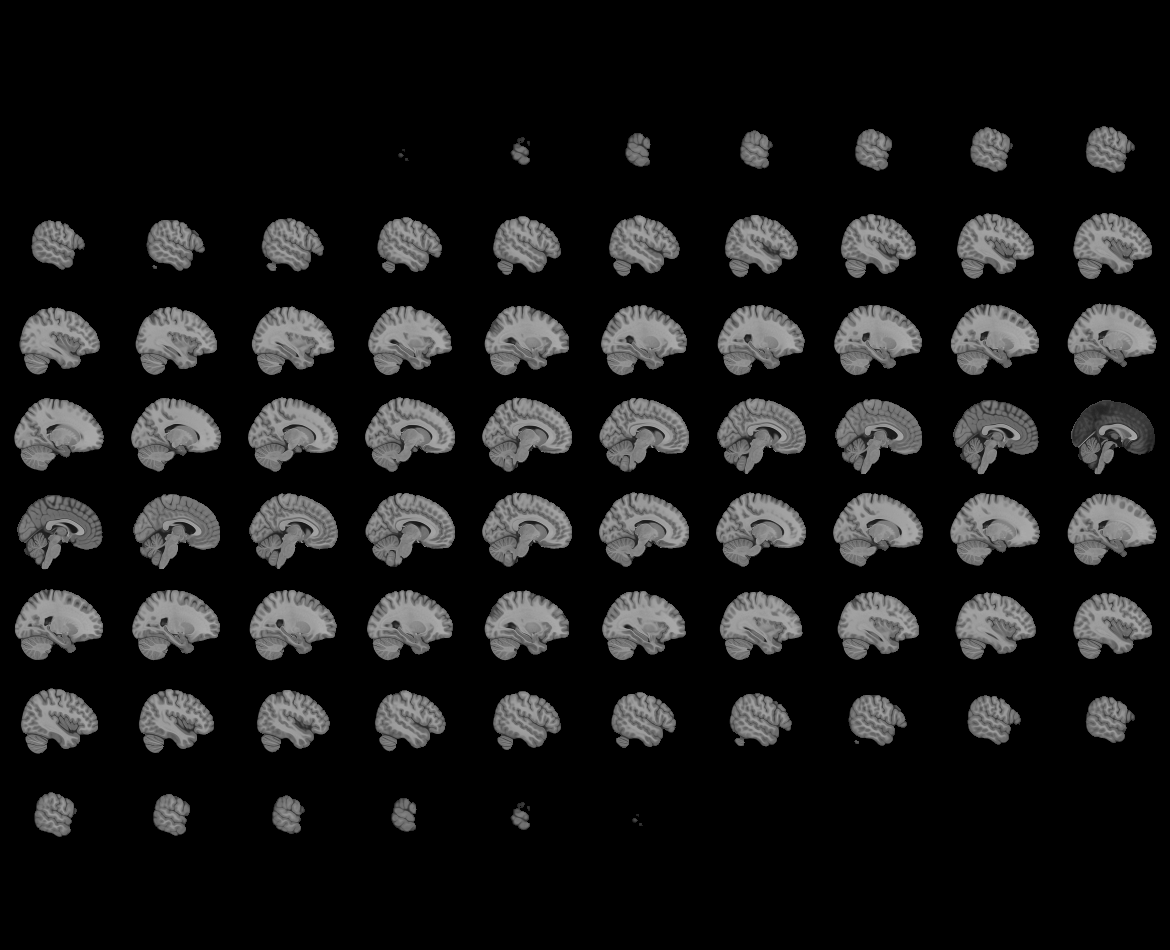
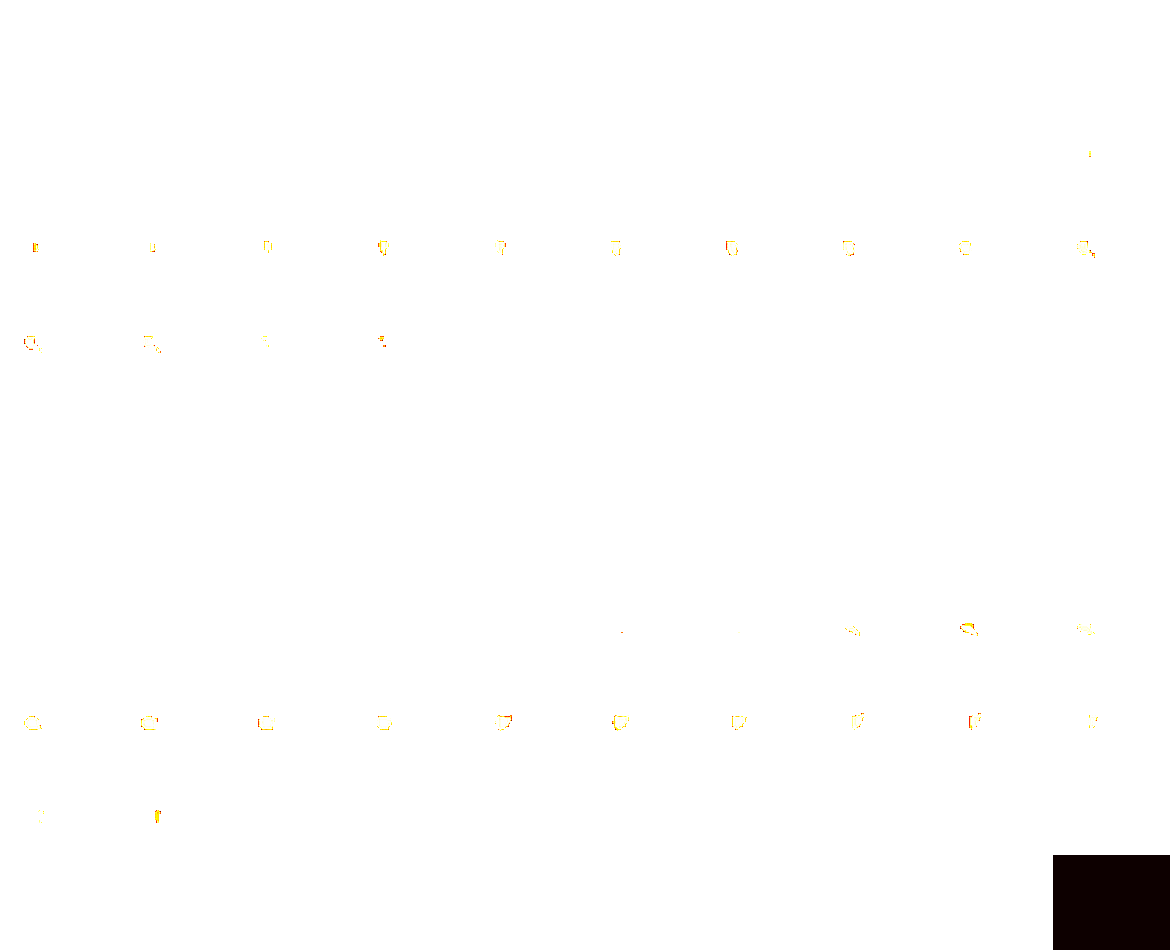

In [7]:
# 7. Visualize the significant voxel centers
view = plotting.view_img(beh_mask)
view

In [15]:
cliptxt_tmap = nib.load(os.path.join("../IAPS_Searchlight/outputs/tBrainmap", 'tmap_cliptxt_p001_fisherz_fdr001.nii.gz'))
# Convert all nonzero values in loc_img to 1, and the rest to 0
cliptxt_mask_data = (cliptxt_tmap.get_fdata() != 0).astype(int)
# Create a new NIfTI image for the binary visual mask
cliptxt_mask = new_img_like(cliptxt_tmap, cliptxt_mask_data)
# Define the output file path
# output_file_path = r"F:\yujun\projects\IAPS_Searchlight\data\masks\gist_mask.nii.gz"
output_file_path = r"..\IAPS_Searchlight\data\masks\cliptxt_mask.nii.gz"

# Save the visual mask image as a .nii.gz file
cliptxt_mask.to_filename(output_file_path)


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_22760\2615244430.py:5: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  cliptxt_mask = new_img_like(cliptxt_tmap, cliptxt_mask_data)


In [ ]:
gist_tmap = nib.load(os.path.join("../IAPS_Searchlight/outputs/tBrainmap", 'tmap_gist_norm_p001.nii.gz'))
# Convert all nonzero values in loc_img to 1, and the rest to 0
gist_mask_data = (gist_tmap.get_fdata() != 0).astype(int)
# Create a new NIfTI image for the binary visual mask
gist_mask = new_img_like(gist_tmap, gist_mask_data)
# Define the output file path
output_file_path = r"..\IAPS_Searchlight\data\masks\gist_mask.nii.gz"

# Save the visual mask image as a .nii.gz file
gist_mask.to_filename(output_file_path)

In [ ]:

# clipvit_tmap = nib.load(os.path.join("../IAPS_Searchlight/outputs/tBrainmap", 'tmap_purevit_p001_fisherz_fdr01.nii.gz'))
# clipvit_tmap = nib.load(os.path.join("../IAPS_Searchlight/outputs/tBrainmap", 'tmap_purevit_ple8_fisherz_fdr01.nii.gz'))


# # Convert all nonzero values in loc_img to 1, and the rest to 0
# clipvit_mask_data = (clipvit_tmap.get_fdata() != 0).astype(int)
# # Create a new NIfTI image for the binary visual mask
# clipvit_mask = new_img_like(clipvit_tmap, clipvit_mask_data)
# # Define the output file path
# # output_file_path = r"F:\yujun\projects\IAPS_Searchlight\data\masks\gist_mask.nii.gz"
# output_file_path = r"..\IAPS_Searchlight\data\masks\clipvit_mask.nii.gz"

# # Save the visual mask image as a .nii.gz file
# clipvit_mask.to_filename(output_file_path)




C:\Users\yujunchen\AppData\Local\Temp\ipykernel_22760\1750272708.py:8: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  gist_mask = new_img_like(gist_tmap, gist_mask_data)
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_22760\1750272708.py:18: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  clipvit_mask = new_img_like(clipvit_tmap, clipvit_mask_data)


In [19]:
gist_mask = nib.load(os.path.join("..\IAPS_Searchlight\data\masks\gist_mask.nii.gz"))

c:\Users\yujunchen\AppData\Local\miniconda3\envs\neuro161\lib\site-packages\numpy\_core\fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\AppData\Local\miniconda3\envs\neuro161\lib\site-packages\nilearn\image\resampling.py:805: UserWarning: Casting data from int32 to float32
  return resample_img(
c:\Users\yujunchen\AppData\Local\miniconda3\envs\neuro161\lib\site-packages\nilearn\image\resampling.py:297: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  warnings.warn(



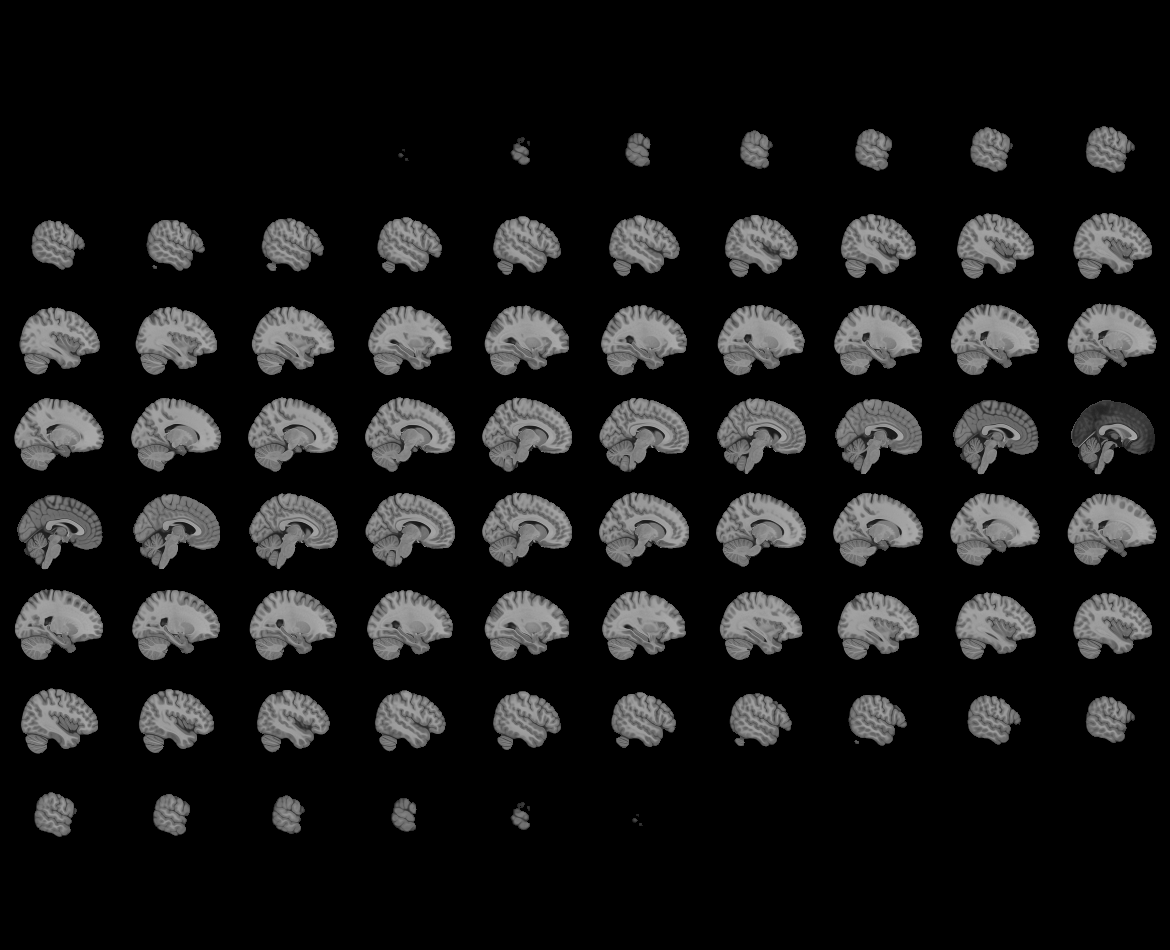
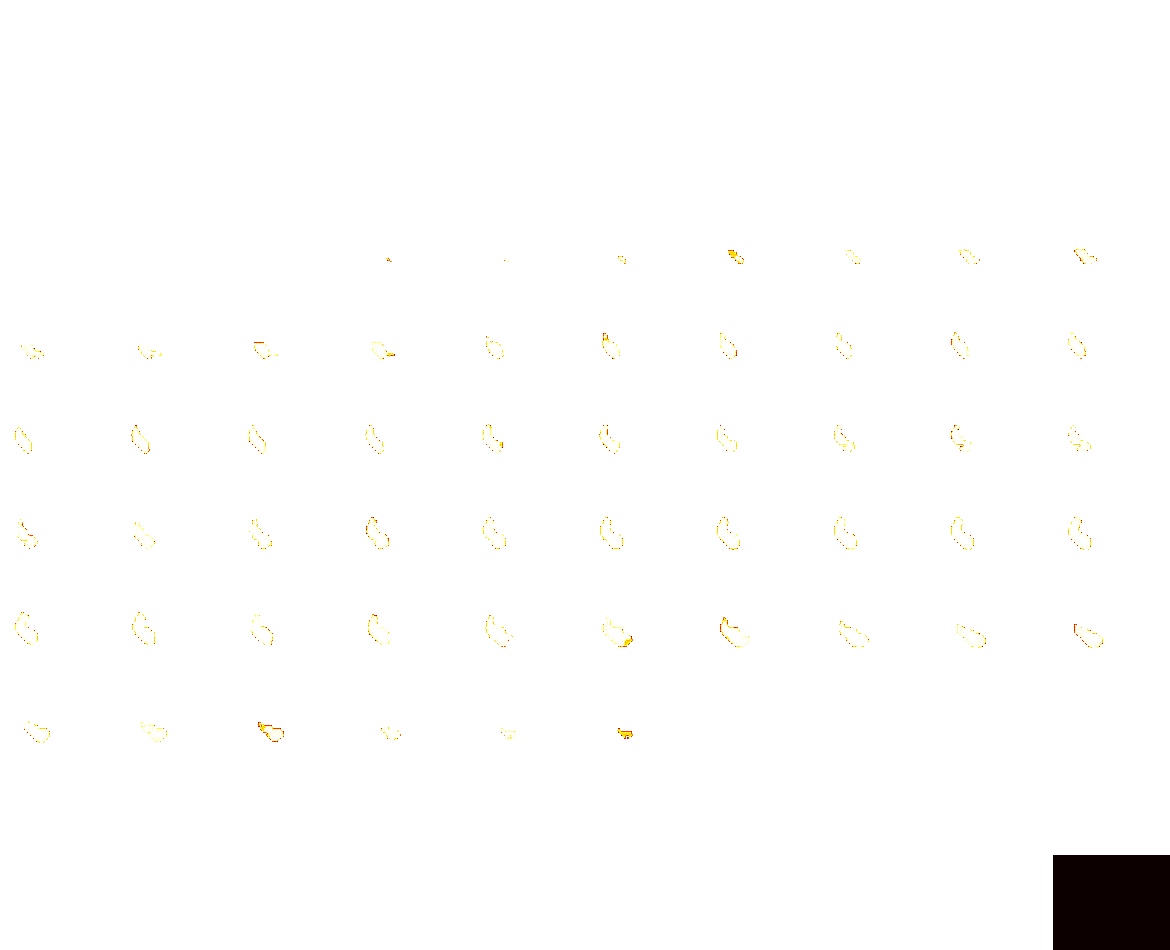

In [17]:
# 7. Visualize the significant voxel centers
view = plotting.view_img(gist_mask)
view

In [20]:
cliptxt_mask = nib.load(os.path.join("..\IAPS_Searchlight\data\masks\cliptxt_mask.nii.gz"))

c:\Users\yujunchen\AppData\Local\miniconda3\envs\neuro161\lib\site-packages\numpy\_core\fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\AppData\Local\miniconda3\envs\neuro161\lib\site-packages\nilearn\image\resampling.py:805: UserWarning: Casting data from int32 to float32
  return resample_img(
c:\Users\yujunchen\AppData\Local\miniconda3\envs\neuro161\lib\site-packages\nilearn\image\resampling.py:297: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  warnings.warn(



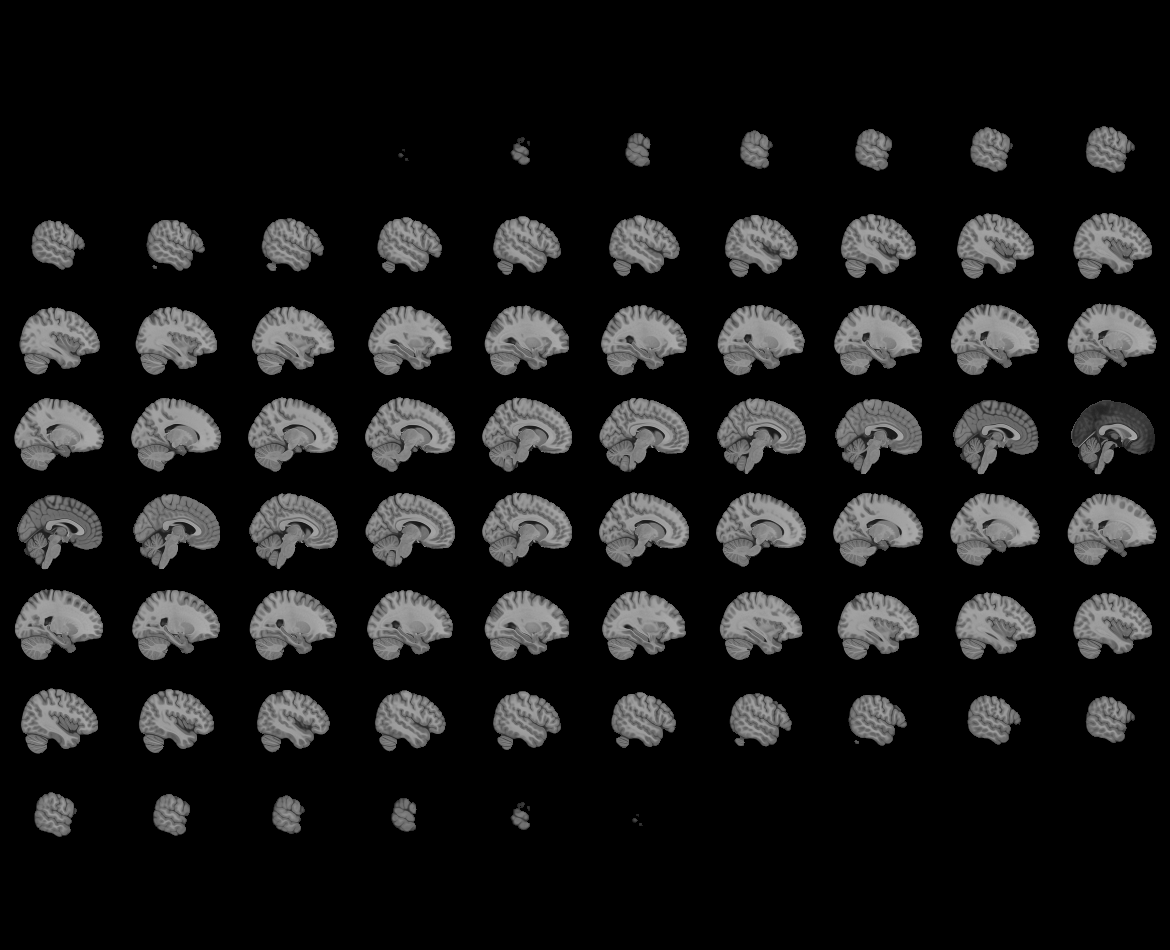
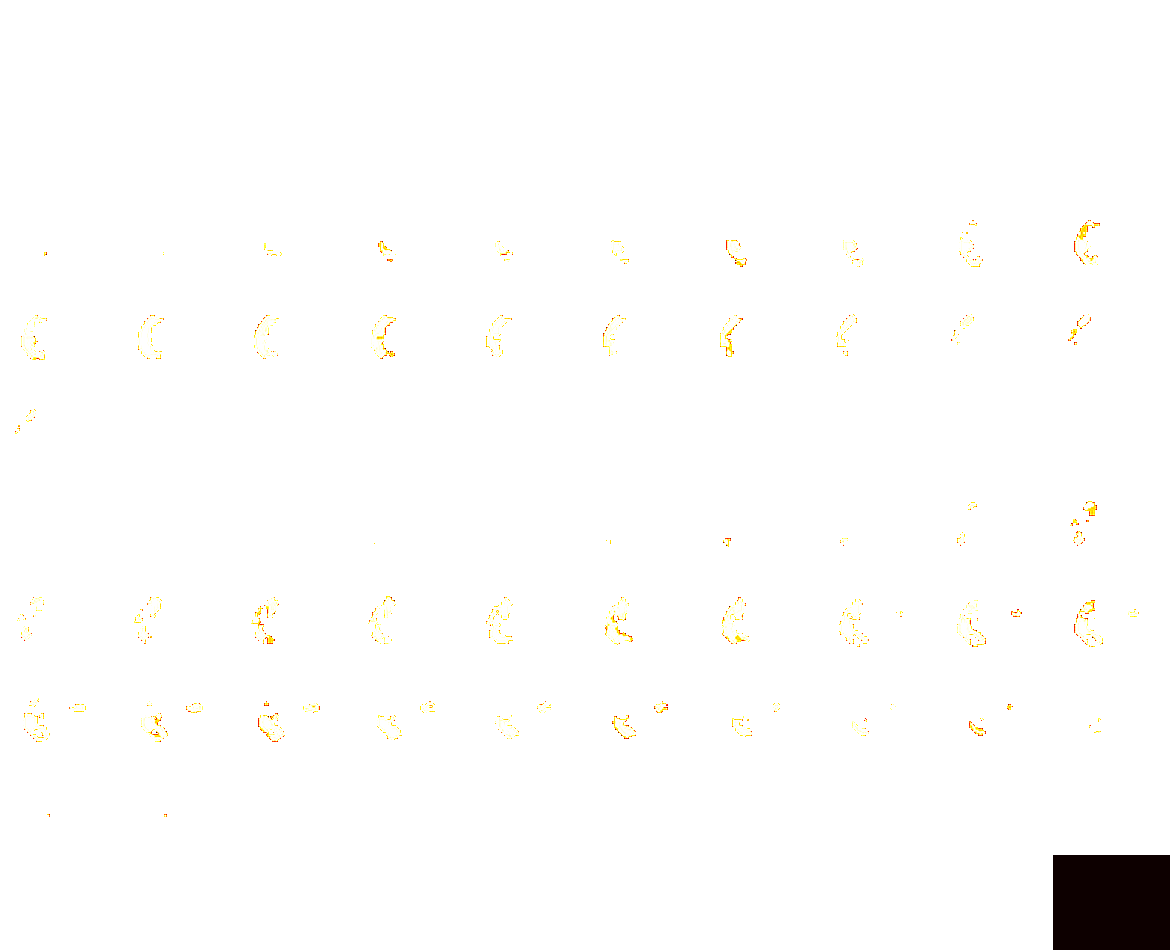

In [21]:
# 7. Visualize the significant voxel centers
view = plotting.view_img(cliptxt_mask)
view

# EEG RDMs

In [23]:
# Function to compute EEG RDMs
def compute_eeg_rdms(eeg_arr, metric='correlation'):
    """
    Compute EEG RDMs based on the 31 EEG channels across stimuli and time points.

    Parameters:
        eeg_arr (numpy array): EEG data of shape (20, 31, 60, 575)
                              (subjects, channels, stimuli, time points).
        metric (str): Distance metric to use for RDM computation (e.g., 'correlation', 'euclidean').

    Returns:
        eeg_rdms (numpy array): RDMs of shape (20, 60, 60, 575)
                                (subjects, stimuli x stimuli, time points).
    """
    n_subjects, n_channels, n_stimuli, n_timepoints = eeg_arr.shape
    eeg_rdms = np.zeros((n_subjects, n_stimuli, n_stimuli, n_timepoints))

    # Iterate over subjects
    for subj in range(n_subjects):
        print(f"Processing Subject {subj + 1}/{n_subjects}...")
        
        # Iterate over time points
        for t in range(n_timepoints):
            # Extract data at time point t for all stimuli (shape: 60, 31)
            data_at_t = eeg_arr[subj, :, :, t].T  # Transpose to shape (60, 31)
            
            # Compute pairwise distances (RDM) between stimuli
            rdm = pairwise_distances(data_at_t, metric=metric)  # Shape: (60, 60)
            
            # Store the RDM
            eeg_rdms[subj, :, :, t] = rdm

    return eeg_rdms

# Example usage
eeg_rdms = compute_eeg_rdms(eeg_arr, metric='correlation')  # Output: (20, 60, 60, 575)

# Print the resulting shape
print("Shape of EEG RDMs:", eeg_rdms.shape)


Processing Subject 1/20...
Processing Subject 2/20...
Processing Subject 3/20...
Processing Subject 4/20...
Processing Subject 5/20...
Processing Subject 6/20...
Processing Subject 7/20...
Processing Subject 8/20...
Processing Subject 9/20...
Processing Subject 10/20...
Processing Subject 11/20...
Processing Subject 12/20...
Processing Subject 13/20...
Processing Subject 14/20...
Processing Subject 15/20...
Processing Subject 16/20...
Processing Subject 17/20...
Processing Subject 18/20...
Processing Subject 19/20...
Processing Subject 20/20...
Shape of EEG RDMs: (20, 60, 60, 575)


# ROI fmri RDM 

In [24]:
gist_mask_data = gist_mask.get_fdata() > 0  # Motor mask binary
beh_mask_data = beh_mask.get_fdata() > 0  # Motor mask binary
# clipvit_mask_data = clipvit_mask.get_fdata() > 0  # Motor mask binary
cliptxt_mask_data = cliptxt_mask.get_fdata() > 0  # Motor mask binary
brain_data = allsub_avg.reshape(20, 60, *gist_mask_data.shape)
brain_data.shape

(20, 60, 53, 63, 46)

In [26]:
# Apply the function
print("Calculating GIST-EVC RDMs...")
gist_fmri_rdms = compute_rdm(brain_data, gist_mask_data, "GIST-EVC Mask")  # Shape: (20, 60, 60)

# Print shapes for verification
print("\GIST-EVC RDMs shape:", gist_fmri_rdms.shape)  # Should be (20, 60, 60)
    # Should be (20, 60, 60)

print("Calculating Behaior-OTC RDMs...")
beh_fmri_rdms = compute_rdm(brain_data, beh_mask_data, "Behaior-OTC Mask")  # Shape: (20, 60, 60)

# Print shapes for verification
print("\nBehaior-OTC RDMs shape:", beh_fmri_rdms.shape)  # Should be (20, 60, 60)
    # Should be (20, 60, 60)

print("Calculating CLIP-text embeddings fmri RDMs...")
cliptxt_fmri_rdms = compute_rdm(brain_data, cliptxt_mask_data, "CLIP-text embeddings Mask")  # Shape: (20, 60, 60)

# Print shapes for verification
print("\nCLIP-text embeddings RDMs shape:", cliptxt_fmri_rdms.shape)  # Should be (20, 60, 60)
    # Should be (20, 60, 60)

Calculating GIST-EVC RDMs...
GIST-EVC Mask: Total voxel count in mask: 4186
Subject 1: Masked data contains 1380 NaN values. Total voxel count in mask: 4186.
Subject 1: 4163 out of 4186 masked voxels are completely valid (non-NaN).
Subject 2: Masked data contains 60 NaN values. Total voxel count in mask: 4186.
Subject 2: 4185 out of 4186 masked voxels are completely valid (non-NaN).
Subject 3: All 4186 masked voxels are valid (non-NaN).
Subject 4: All 4186 masked voxels are valid (non-NaN).
Subject 5: Masked data contains 180 NaN values. Total voxel count in mask: 4186.
Subject 5: 4183 out of 4186 masked voxels are completely valid (non-NaN).
Subject 6: Masked data contains 1200 NaN values. Total voxel count in mask: 4186.
Subject 6: 4166 out of 4186 masked voxels are completely valid (non-NaN).
Subject 7: Masked data contains 120 NaN values. Total voxel count in mask: 4186.
Subject 7: 4184 out of 4186 masked voxels are completely valid (non-NaN).
Subject 8: Masked data contains 1200 N

# RSA

In [27]:
# Compute correlations for loc_rdms and motor_rdms with eeg_rdms
gistevc_rsa = correlate_rdms(gist_fmri_rdms, eeg_rdms)       # Shape: (20, 575)
# Print resulting shapes for verification
print("EVC RDM-EEG RDM Correlations shape:", gistevc_rsa.shape)  # (20, 575)

behotc_rsa = correlate_rdms(beh_fmri_rdms, eeg_rdms)       # Shape: (20, 575)
# Print resulting shapes for verification
print("EVC RDM-EEG RDM Correlations shape:", behotc_rsa.shape)  # (20, 575)

cliptxt_rsa = correlate_rdms(cliptxt_fmri_rdms, eeg_rdms)       # Shape: (20, 575)
# Print resulting shapes for verification
print("EVC RDM-EEG RDM Correlations shape:", cliptxt_rsa.shape)  # (20, 575)




EVC RDM-EEG RDM Correlations shape: (20, 575)
EVC RDM-EEG RDM Correlations shape: (20, 575)
EVC RDM-EEG RDM Correlations shape: (20, 575)


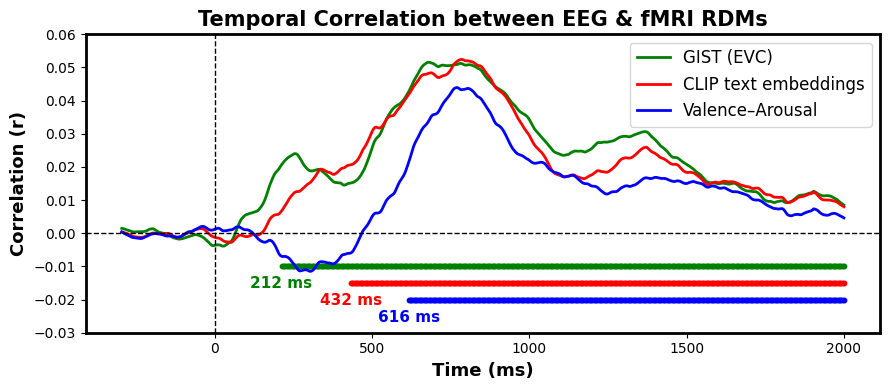

In [46]:
import numpy as np
import matplotlib.pyplot as plt



# ------------------------------------------------------------------
# 0)  Your three subject-level RSA matrices
#      • gistevc_rsa   : (subjects, 575) or (trials, 575)  – EVC (GIST)
#      • behotc_rsa    : (subjects, 575)                  – Valence/Arousal
#      • cliptxt_rsa   : (subjects, 575)                  – CLIP-text
# ------------------------------------------------------------------
# >>>  make sure these are already loaded into the workspace  <<<

# ------------------------------------------------------------------
# 1)  Rescale and shift the x-axis (4 ms per sample, –300 ms offset)
# ------------------------------------------------------------------
x           = np.arange(1, 576)           # 1 … 575
x_rescaled  = x * 4                       # → 4 … 2300 ms
x_shifted   = x_rescaled - 300            # –296 … 2000 ms

# index of first point ≥ 0 ms  ⇒ baseline = points < 0 ms
baseline_idx = np.where(x_shifted >= 0)[0][0]

# ------------------------------------------------------------------
# 2)  EVC (GIST)
# ------------------------------------------------------------------
mean_corr_evc = np.mean(gistevc_rsa, axis=0)
baseline_corr_evc = np.mean(mean_corr_evc[:baseline_idx])
corrected_corr_evc = mean_corr_evc - baseline_corr_evc
smoothed_corr_evc = smooth(corrected_corr_evc)

# baseline distribution for sig-test (use same window as original code)
baseline_mean_evc = np.mean(np.mean(gistevc_rsa[:, :baseline_idx], axis=0))
baseline_std_evc  = np.std(np.mean(gistevc_rsa[:, :baseline_idx], axis=0))

sig_idx_evc = find_significant_clusters(smoothed_corr_evc,
                                        baseline_mean_evc,
                                        baseline_std_evc)
if len(sig_idx_evc):
    first_evc_idx = sig_idx_evc[0]
    sig_idx_evc   = np.arange(first_evc_idx, len(smoothed_corr_evc))

# ------------------------------------------------------------------
# 3)  OTC (Valence + Arousal)
# ------------------------------------------------------------------
mean_corr_va     = np.mean(behotc_rsa, axis=0)
baseline_corr_va = np.mean(mean_corr_va[:baseline_idx])
corrected_corr_va = mean_corr_va - baseline_corr_va
smoothed_corr_va = smooth(corrected_corr_va)

baseline_mean_va = np.mean(np.mean(gistevc_rsa[:, :baseline_idx], axis=0))  # same baseline
baseline_std_va  = np.std(np.mean(gistevc_rsa[:, :baseline_idx], axis=0))

sig_idx_va = find_significant_clusters(smoothed_corr_va,
                                       baseline_mean_va,
                                       baseline_std_va)
if len(sig_idx_va):
    first_va_idx = sig_idx_va[0]
    sig_idx_va   = np.arange(first_va_idx, len(smoothed_corr_va))

# ------------------------------------------------------------------
# 4)  CLIP text embeddings
# ------------------------------------------------------------------
mean_corr_clip     = np.mean(cliptxt_rsa, axis=0)
baseline_corr_clip = np.mean(mean_corr_clip[:baseline_idx])
corrected_corr_clip = mean_corr_clip - baseline_corr_clip
smoothed_corr_clip = smooth(corrected_corr_clip)

baseline_mean_clip = np.mean(np.mean(cliptxt_rsa[:, :baseline_idx], axis=0))
baseline_std_clip  = np.std(np.mean(cliptxt_rsa[:, :baseline_idx], axis=0))

sig_idx_clip = find_significant_clusters(smoothed_corr_clip,
                                         baseline_mean_clip,
                                         baseline_std_clip)
if len(sig_idx_clip):
    first_clip_idx = sig_idx_clip[0]
    sig_idx_clip   = np.arange(first_clip_idx, len(smoothed_corr_clip))

# ------------------------------------------------------------------
# 5)  Plot
# ------------------------------------------------------------------
plt.style.use("default")
fig, ax = plt.subplots(figsize=(9, 4))

# ­­­— main curves ———————————————————————————————
ax.plot(x_shifted, smoothed_corr_evc,
        label="GIST (EVC)", color="green", linewidth=2)
ax.plot(x_shifted, smoothed_corr_clip,
        label="CLIP text embeddings", color="red", linewidth=2)
ax.plot(x_shifted, smoothed_corr_va,
        label="Valence–Arousal", color="blue", linewidth=2)

# — y-levels for significance dots (top → bottom) —
y_sig_gist = -0.010   # top row
y_sig_clip = -0.015   # middle row
y_sig_va   = -0.020   # bottom row

# ­­­— GIST sig markers —————————————————————————————
if len(sig_idx_evc):
    ax.scatter(x_shifted[sig_idx_evc],
               [y_sig_gist] * len(sig_idx_evc),
               color="green", s=10)
    first_time = x_shifted[first_evc_idx]
    ax.text(first_time, y_sig_gist - 0.003,
            f"{first_time} ms", color="green",
            fontsize=11, fontweight="bold", ha="center", va="top")

# ­­­— CLIP sig markers —————————————————————————————
if len(sig_idx_clip):
    ax.scatter(x_shifted[sig_idx_clip],
               [y_sig_clip] * len(sig_idx_clip),
               color="red", s=10)
    first_time = x_shifted[first_clip_idx]
    ax.text(first_time, y_sig_clip - 0.003,
            f"{first_time} ms", color="red",
            fontsize=11, fontweight="bold", ha="center", va="top")

# ­­­— Valence–Arousal sig markers ———————————————
if len(sig_idx_va):
    ax.scatter(x_shifted[sig_idx_va],
               [y_sig_va] * len(sig_idx_va),
               color="blue", s=10)
    first_time = x_shifted[first_va_idx]
    ax.text(first_time, y_sig_va - 0.003,
            f"{first_time} ms", color="blue",
            fontsize=11, fontweight="bold", ha="center", va="top")

# ­­­— styling ———————————————————————————————————————
ax.set_ylim([-0.03, 0.06])
ax.axvline(0,  color="black", linestyle="--", linewidth=1)
ax.axhline(0,  color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Time (ms)", fontsize=13, fontweight="bold")
ax.set_ylabel("Correlation (r)", fontsize=13, fontweight="bold")
ax.set_title("Temporal Correlation between EEG & fMRI RDMs",
             fontsize=15, fontweight="bold")
ax.legend(loc="upper right", fontsize=12)

# thicker outer box
for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()
plt.show()


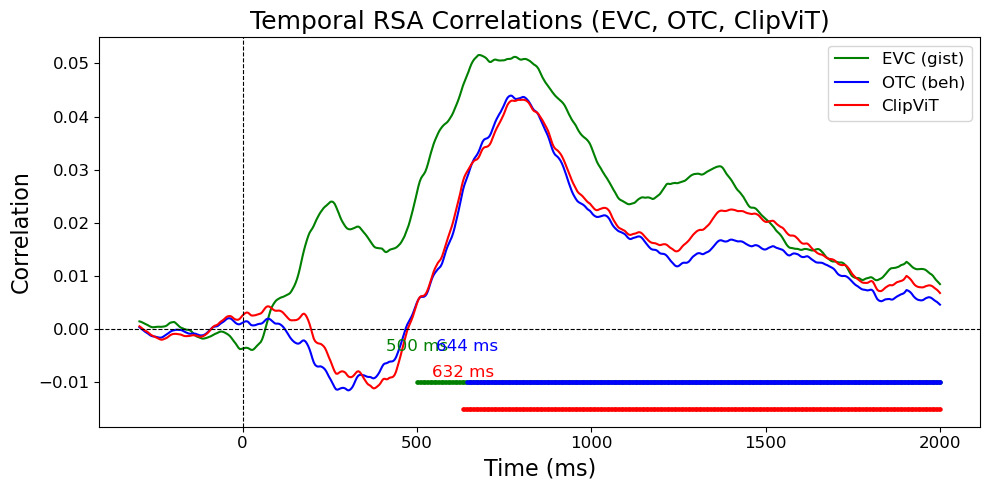

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# --- Helper functions assumed to be defined ---
# For example:
# def smooth(data):
#     # Your smoothing function here
#     return data
#
# def find_significant_clusters(data, baseline_mean, baseline_std):
#     # Your cluster detection function here; return indices where data is significant
#     return np.where(data > (baseline_mean + 2 * baseline_std))[0]

#---------------------------------------------------
# 1) Rescale and shift the x-axis
#---------------------------------------------------
x = np.arange(1, 576, 1)
x_rescaled = [i * 4 for i in x]
x_shifted = np.array([i - 300 for i in x_rescaled])

# Identify index corresponding to 0 ms (everything before 0ms is baseline)
zero_index = np.where(x_shifted >= 0)[0][0]
baseline_index = zero_index

#---------------------------------------------------
# 2) EVC: Compute mean, baseline-correct, smooth (using gistevc_rsa)
#---------------------------------------------------
mean_baseline_corr_evc = np.mean(gistevc_rsa[:, :baseline_index], axis=0)
baseline_mean_corr_evc = np.mean(mean_baseline_corr_evc)
baseline_std_corr_evc = np.std(mean_baseline_corr_evc)

mean_corr_evc = np.mean(gistevc_rsa, axis=0)
baseline_correction_evc = np.mean(mean_corr_evc[:baseline_index])
corrected_corr_evc = mean_corr_evc - baseline_correction_evc
smoothed_corr_evc = smooth(corrected_corr_evc)

significant_evc_indices = find_significant_clusters(
    smoothed_corr_evc,
    baseline_mean_corr_evc,
    baseline_std_corr_evc
)
if len(significant_evc_indices) > 0:
    first_evc_index = significant_evc_indices[0]
    significant_evc_indices = np.arange(first_evc_index, len(smoothed_corr_evc))

#---------------------------------------------------
# 3) OTC: Compute mean, baseline-correct, smooth (using behotc_rsa)
#---------------------------------------------------
# Note: The baseline here is computed from gistevc_rsa, as in your original code.
mean_baseline_corr_loc = np.mean(gistevc_rsa[:, :baseline_index], axis=0)
baseline_mean_corr_loc = np.mean(mean_baseline_corr_loc)
baseline_std_corr_loc = np.std(mean_baseline_corr_loc)

mean_corr_loc = np.mean(behotc_rsa, axis=0)
baseline_correction_loc = np.mean(mean_corr_loc[:baseline_index])
corrected_corr_loc = mean_corr_loc - baseline_correction_loc
smoothed_corr_loc = smooth(corrected_corr_loc)

significant_loc_indices = find_significant_clusters(
    smoothed_corr_loc,
    baseline_mean_corr_loc,
    baseline_std_corr_loc
)
if len(significant_loc_indices) > 0:
    first_loc_index = significant_loc_indices[0]
    significant_loc_indices = np.arange(first_loc_index, len(smoothed_corr_loc))

#---------------------------------------------------
# 4) ClipViT: Compute mean, baseline-correct, smooth (using clipvit_rsa)
#---------------------------------------------------
mean_baseline_corr_clipvit = np.mean(clipvit_rsa[:, :baseline_index], axis=0)
baseline_mean_corr_clipvit = np.mean(mean_baseline_corr_clipvit)
baseline_std_corr_clipvit = np.std(mean_baseline_corr_clipvit)

mean_corr_clipvit = np.mean(clipvit_rsa, axis=0)
baseline_correction_clipvit = np.mean(mean_corr_clipvit[:baseline_index])
corrected_corr_clipvit = mean_corr_clipvit - baseline_correction_clipvit
smoothed_corr_clipvit = smooth(corrected_corr_clipvit)

significant_clipvit_indices = find_significant_clusters(
    smoothed_corr_clipvit,
    baseline_mean_corr_clipvit,
    baseline_std_corr_clipvit
)
if len(significant_clipvit_indices) > 0:
    first_clipvit_index = significant_clipvit_indices[0]
    significant_clipvit_indices = np.arange(first_clipvit_index, len(smoothed_corr_clipvit))

#---------------------------------------------------
# 5) Plot the results
#---------------------------------------------------
plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 4))

# Optionally, set y-limit (adjust as needed)
ax.set_ylim([-0.02, 0.06])

# Thicken the axes spines (heavier outer box)
for spine in ax.spines.values():
    spine.set_linewidth(2)

# Plot EVC correlation (thicker line)
ax.plot(x_shifted, smoothed_corr_evc,
        label='EVC correlation',
        color='green', linewidth=2)

# Mark EVC significant points
if len(significant_evc_indices) > 0:
    ax.scatter(
        x_shifted[significant_evc_indices],
        [-0.01] * len(significant_evc_indices),
        color='green', s=10
    )
    first_evc_time = x_shifted[first_evc_index]
    ax.text(first_evc_time, -0.01 + 0.006,
            f'{first_evc_time} ms',
            color='green', fontsize=13, fontweight='bold',
            ha='center', va='top')

# Plot OTC correlation (thicker line)
ax.plot(x_shifted, smoothed_corr_loc,
        label='OTC correlation',
        color='blue', linewidth=2)

# Mark OTC significant points
if len(significant_loc_indices) > 0:
    ax.scatter(
        x_shifted[significant_loc_indices],
        [-0.015] * len(significant_loc_indices),
        color='blue', s=10
    )
    first_loc_time = x_shifted[first_loc_index]
    ax.text(first_loc_time, -0.015 + 0.006,
            f'{first_loc_time} ms',
            color='blue', fontsize=13, fontweight='bold',
            ha='center', va='top')

# Plot ClipViT correlation (thicker line)
ax.plot(x_shifted, smoothed_corr_clipvit,
        label='ClipViT correlation \n (ROI, FDR p=0.001)',
        color='red', linewidth=2)

# Mark ClipViT significant points
if len(significant_clipvit_indices) > 0:
    ax.scatter(
        x_shifted[significant_clipvit_indices],
        [-0.02] * len(significant_clipvit_indices),
        color='red', s=10
    )
    first_clipvit_time = x_shifted[first_clipvit_index]
    ax.text(first_clipvit_time, -0.02 + 0.006,
            f'{first_clipvit_time} ms',
            color='red', fontsize=13, fontweight='bold',
            ha='center', va='top')

# Dashed lines at x=0 and y=0
ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.axhline(0.0, color='black', linewidth=1, linestyle='--')

# Bold, larger axis labels
ax.set_xlabel('Time (ms)', fontsize=13, fontweight='bold')
ax.set_ylabel('Correlation', fontsize=13, fontweight='bold')

# Bold, larger tick labels
ax.tick_params(axis='both', labelsize=10)

# Bold, larger title
ax.set_title('Temporal Correlation between EEG RDMs and fMRI RDMs', 
             fontsize=15, fontweight='bold')

# Legend inside plot with bigger font
ax.legend(loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()


# ROI: CLIP ViT excluding Beh

In [90]:
# Load your masks
beh_mask = nib.load(r"F:\yujun\projects\IAPS_Searchlight\data\masks\loc_mask.nii.gz")
clipvit_tmap = nib.load(os.path.join(r"F:\yujun\projects\IAPS_Searchlight\outputs\tBrainmap", 
                                     'tmap_purevit_p001_fisherz_fdr01.nii.gz'))

# Build binary masks
beh_data     = beh_mask.get_fdata().astype(bool)
clipvit_data = (clipvit_tmap.get_fdata() != 0)

# Subtract overlap: keep only voxels in ClipViT that are NOT in beh_mask
unique_clipvit = np.logical_and(clipvit_data, ~beh_data).astype(int)

# Create a new NIfTI image and save it
unique_clipvit_img = new_img_like(clipvit_tmap, unique_clipvit)
output_path = r"F:\yujun\projects\IAPS_Searchlight\data\masks\clipvit_unique_mask.nii.gz"
unique_clipvit_img.to_filename(output_path)

# print(f"Saved unique ClipViT mask (no overlap with LOC) to:\n{output_path}")


c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\numpy\core\fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\nilearn\image\resampling.py:756: UserWarning: Casting data from int32 to float32
  return resample_img(
c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\nilearn\image\resampling.py:293: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  warnings.warn(
c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\nilearn\plotting\html_document.py:102: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  warnings.warn(



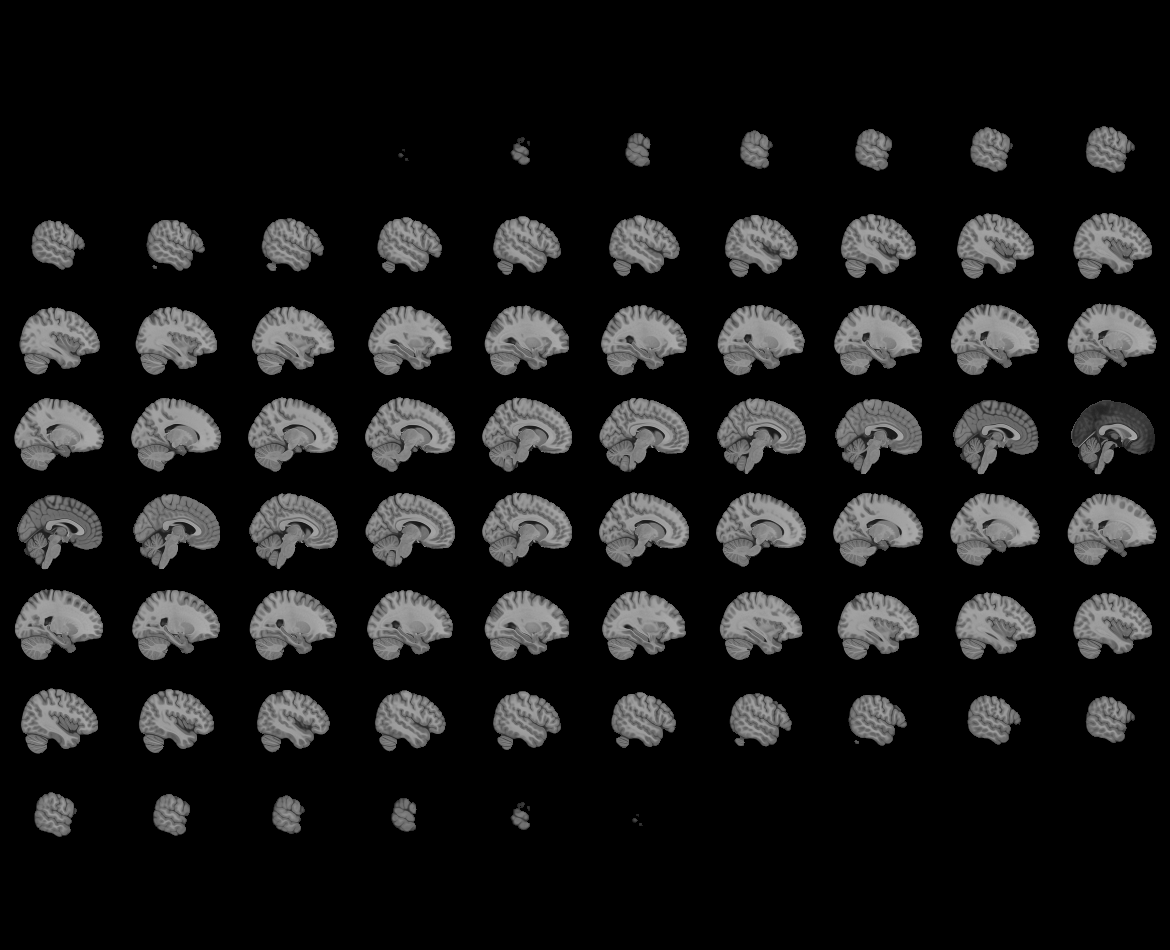
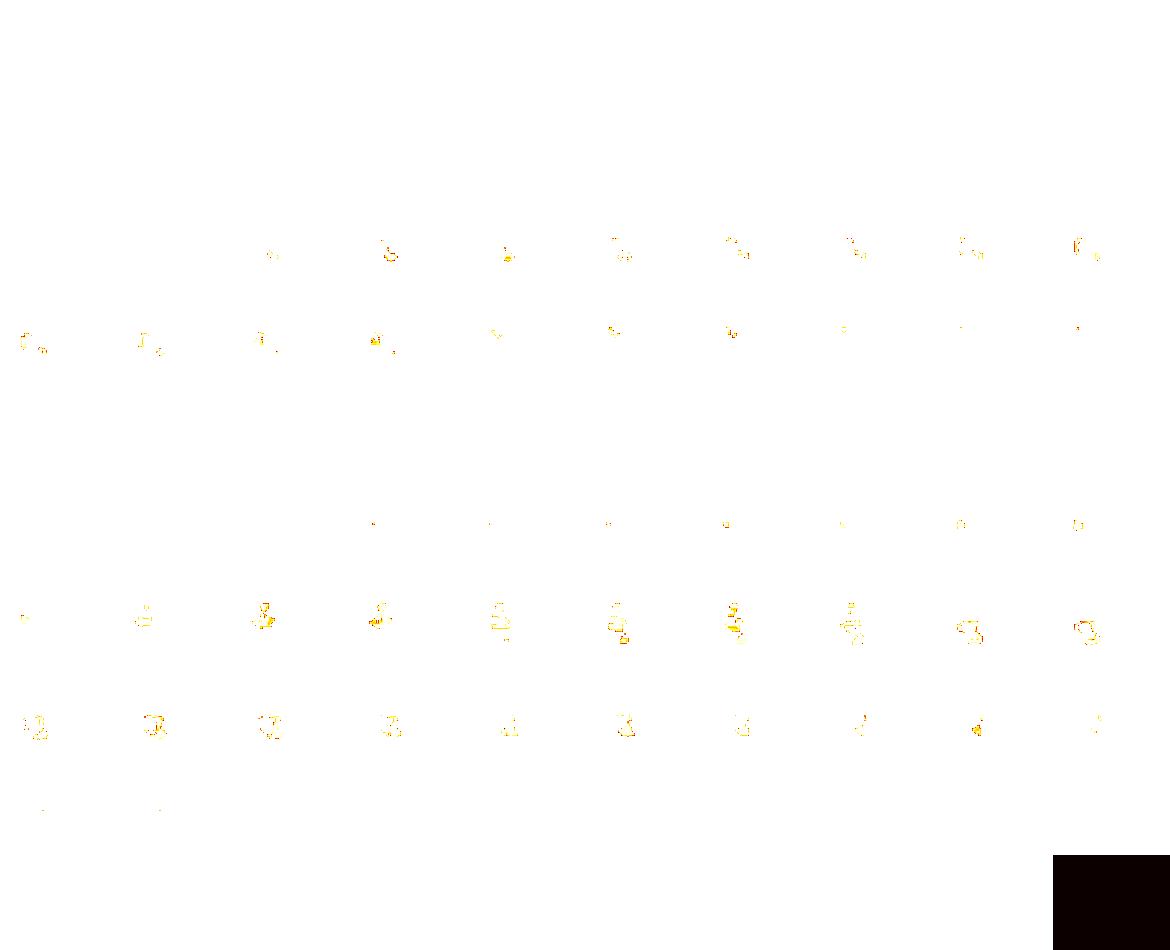

In [89]:
# 7. Visualize the significant voxel centers
view = plotting.view_img(unique_clipvit_img)
view

In [ ]:
unique_clipvit_mask = nib.load(r"F:\yujun\projects\IAPS_Searchlight\data\masks\clipvit_unique_mask.nii.gz")
unique_clipvit_mask_data = unique_clipvit_mask.get_fdata() > 0

# Compute fMRI RDMs for unique ClipViT ROI
print("Calculating CLIP-ViT UNIQUE RDMs...")
clipvit_unique_fmri_rdms = compute_rdm(brain_data, unique_clipvit_mask_data, "ClipViT Unique Mask")
print("CLIP-ViT UNIQUE RDMs shape:", clipvit_unique_fmri_rdms.shape)

# Correlate with EEG RDMs
clipvit_unique_rsa = correlate_rdms(clipvit_unique_fmri_rdms, eeg_rdms)
print("ClipViT UNIQUE RDM‑EEG RDM Correlations shape:", clipvit_unique_rsa.shape)

# Replace all occurrences of clipvit_rsa in your pipeline with clipvit_unique_rsa
# (Below is just the ClipViT block from your plotting code — integrate it where you already compute EVC & OTC)

#---------------------------------------------------
# ClipViT UNIQUE: Compute mean, baseline-correct, smooth
#---------------------------------------------------
mean_baseline_corr_clip = np.mean(clipvit_unique_rsa[:, :baseline_index], axis=0)
baseline_mean_corr_clip = np.mean(mean_baseline_corr_clip)
baseline_std_corr_clip = np.std(mean_baseline_corr_clip)

mean_corr_clip = np.mean(clipvit_unique_rsa, axis=0)
baseline_correction_clip = np.mean(mean_corr_clip[:baseline_index])
corrected_corr_clip = mean_corr_clip - baseline_correction_clip
smoothed_corr_clip = smooth(corrected_corr_clip)

significant_clip_indices = find_significant_clusters(
    smoothed_corr_clip,
    baseline_mean_corr_clip,
    baseline_std_corr_clip
)
if len(significant_clip_indices) > 0:
    first_clip_index = significant_clip_indices[0]
    significant_clip_indices = np.arange(first_clip_index, len(smoothed_corr_clip))

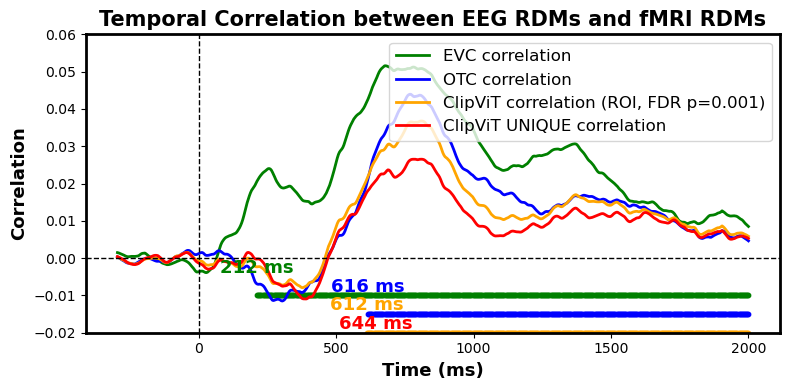

In [93]:
import numpy as np
import matplotlib.pyplot as plt

# --- Assumes gistevc_rsa, behotc_rsa, clipvit_rsa, and clipvit_unique_rsa are already computed ---

#---------------------------------------------------
# 1) Rescale and shift the x-axis
#---------------------------------------------------
x = np.arange(1, 576) * 4 - 300
zero_index = np.where(x >= 0)[0][0]
baseline_index = zero_index

#---------------------------------------------------
# Helper to compute smoothed, baseline‑corrected timecourse + significance
#---------------------------------------------------
def get_timecourse(rsa, baseline_data):
    mean_baseline = np.mean(baseline_data[:, :baseline_index], axis=0)
    base_mean = mean_baseline.mean()
    base_std = mean_baseline.std()

    mean_tc = rsa.mean(axis=0)
    correction = mean_tc[:baseline_index].mean()
    tc = smooth(mean_tc - correction)

    sig_idxs = find_significant_clusters(tc, base_mean, base_std)
    if len(sig_idxs):
        first = sig_idxs[0]
        sig_idxs = np.arange(first, len(tc))
    else:
        first = None
    return tc, sig_idxs, first

# Baseline data always from EVC (gistevc_rsa)
baseline_data = gistevc_rsa

# Compute all four
tc_evc, sig_evc, first_evc = get_timecourse(gistevc_rsa, baseline_data)
tc_otc, sig_otc, first_otc = get_timecourse(behotc_rsa, baseline_data)
tc_clip, sig_clip, first_clip = get_timecourse(clipvit_rsa, baseline_data)
tc_clip_unique, sig_clip_unique, first_clip_unique = get_timecourse(clipvit_unique_rsa, baseline_data)

#---------------------------------------------------
# 2) Plot all four curves
#---------------------------------------------------
plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_ylim([-0.02, 0.06])
for spine in ax.spines.values():
    spine.set_linewidth(2)

# Plot helper
def plot_tc(tc, sig, first, label, color, y_offset):
    ax.plot(x, tc, label=label, color=color, linewidth=2)
    if sig.size:
        ax.scatter(x[sig], [y_offset]*len(sig), color=color, s=10)
        ax.text(x[first], y_offset+0.006, f'{int(x[first])} ms',
                color=color, fontsize=13, fontweight='bold', ha='center')

plot_tc(tc_evc, sig_evc, first_evc, 'EVC correlation', 'green', -0.01)
plot_tc(tc_otc, sig_otc, first_otc, 'OTC correlation', 'blue', -0.015)
plot_tc(tc_clip, sig_clip, first_clip, 'ClipViT correlation (ROI, FDR p=0.001)', 'orange', -0.02)
plot_tc(tc_clip_unique, sig_clip_unique, first_clip_unique, 'ClipViT UNIQUE correlation', 'red', -0.025)

ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.axhline(0, color='black', linestyle='--', linewidth=1)

ax.set_xlabel('Time (ms)', fontsize=13, fontweight='bold')
ax.set_ylabel('Correlation', fontsize=13, fontweight='bold')
ax.set_title('Temporal Correlation between EEG RDMs and fMRI RDMs', fontsize=15, fontweight='bold')
ax.tick_params(axis='both', labelsize=10)
ax.legend(loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()


# ROI: AAL3

In [5]:
aal_rois_files = ['ACCpre',
 'ACCsub',
 'ACCsup',
 'Amygdala',
 'Angular',
 'Calcarine',
 'Caudate',
 'Cerebellum',
 'Cuneus',
 'FrontalInfOper',
 'FrontalInfOrb',
 'FrontalInfTri',
 'FrontalMedOrb',
 'FrontalMid',
 'FrontalSup',
 'FrontalSupMedial',
 'Fusiform',
 'Heschl',
 'Hippocampus',
 'Insula',
 'LC',
 'Lingual',
 'NAcc',
 'OccipitalInf',
 'OccipitalMid',
 'OccipitalSup',
 'OFCant',
 'OFClat',
 'OFCmed',
 'OFCpost',
 'Pallidum',
 'ParacentralLobule',
 'ParaHippocampal',
 'ParietalInf',
 'ParietalSup',
 'Postcentral',
 'Precentral',
 'Precuneus',
 'Putamen',
 'RedN',
 'RolandicOper',
 'SNpc',
 'SNpr',
 'SuppMotorArea',
 'SupraMarginal',
 'TemporalInf',
 'TemporalMid',
 'TemporalPoleMid',
 'TemporalPoleSup',
 'TemporalSup',
 'ThalAV',
 'ThalIL',
 'ThalLGN',
 'ThalLP',
 'ThalMDl',
 'ThalMDm',
 'ThalMGN',
 'ThalPuA',
 'ThalPuI',
 'ThalPuL',
 'ThalPuM',
 'ThalRe',
 'ThalVA',
 'ThalVL',
 'ThalVPL']

In [6]:
# aal_rois_files = os.listdir("F:\yujun\projects\data\masks\AAL3\\new")
aal_rois = [string.split('.')[0] for string in aal_rois_files]
aal_rois

['ACCpre',
 'ACCsub',
 'ACCsup',
 'Amygdala',
 'Angular',
 'Calcarine',
 'Caudate',
 'Cerebellum',
 'Cuneus',
 'FrontalInfOper',
 'FrontalInfOrb',
 'FrontalInfTri',
 'FrontalMedOrb',
 'FrontalMid',
 'FrontalSup',
 'FrontalSupMedial',
 'Fusiform',
 'Heschl',
 'Hippocampus',
 'Insula',
 'LC',
 'Lingual',
 'NAcc',
 'OccipitalInf',
 'OccipitalMid',
 'OccipitalSup',
 'OFCant',
 'OFClat',
 'OFCmed',
 'OFCpost',
 'Pallidum',
 'ParacentralLobule',
 'ParaHippocampal',
 'ParietalInf',
 'ParietalSup',
 'Postcentral',
 'Precentral',
 'Precuneus',
 'Putamen',
 'RedN',
 'RolandicOper',
 'SNpc',
 'SNpr',
 'SuppMotorArea',
 'SupraMarginal',
 'TemporalInf',
 'TemporalMid',
 'TemporalPoleMid',
 'TemporalPoleSup',
 'TemporalSup',
 'ThalAV',
 'ThalIL',
 'ThalLGN',
 'ThalLP',
 'ThalMDl',
 'ThalMDm',
 'ThalMGN',
 'ThalPuA',
 'ThalPuI',
 'ThalPuL',
 'ThalPuM',
 'ThalRe',
 'ThalVA',
 'ThalVL',
 'ThalVPL']

In [7]:
temp_nii_data = nib.load(f'F:\yujun\projects\data\masks\Kastner\IPS.img')

In [16]:
aal3_masks = []

for roi in aal_rois:
    # Construct file path for the ROI mask
    roi_path = f'F:\\yujun\\projects\\data\\masks\\AAL3\\new\\{roi}.nii.gz'
    aal3_nii = nib.load(roi_path)
    # Resample the mask to match the target image (temp_nii_data)
    aal3_resample = resample_img(aal3_nii, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)
    # Create a binary mask (1 for voxels > 0, else 0)
    aal3_bin = np.where(aal3_resample.get_fdata() > 0, 1, 0)
    # Wrap the binary data into a new NIfTI image using the target affine
    aal3_masks.append(nib.Nifti1Image(aal3_bin, temp_nii_data.affine))
    
# Create a dictionary mapping ROI names to their corresponding mask images
aal3_dict = dict(zip(aal_rois, aal3_masks))

# ------------------------------
# 2. Loop through each AAL3 ROI and compute RSA
# ------------------------------
aal3_rsa_dict = {}

for roi_name, roi_mask_img in aal3_dict.items():
    print(f"\nCalculating {roi_name} fmri RDMs...")
    # Convert the mask image to a binary mask (boolean array)
    roi_mask_data = roi_mask_img.get_fdata() > 0

    # Compute fmri RDMs for this ROI (expected shape: (20, 60, 60))
    fmri_rdms = compute_rdm(brain_data, roi_mask_data, f"{roi_name} Mask")
    print(f"{roi_name} RDMs shape: {fmri_rdms.shape}")

    # Compute RSA correlations between fmri RDMs and EEG RDMs (expected shape: (20, 575))
    rsa = correlate_rdms(fmri_rdms, eeg_rdms)
    print(f"{roi_name} RDM-EEG RDM Correlations shape: {rsa.shape}")

    # Save the RSA result in a dictionary keyed by the ROI name
    aal3_rsa_dict[roi_name] = rsa

# Optionally, you can now inspect aal3_rsa_dict for further analysis.

c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\nilearn\image\resampling.py:293: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  warnings.warn(
c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\nilearn\image\resampling.py:293: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  warnings.warn(
c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\nilearn\image\resampling.py:293: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  warnings.warn(
c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\nilearn\image\resampling.py:293: UserWarning: Resampling binary images w


Calculating ACCpre fmri RDMs...
ACCpre Mask: Total voxel count in mask: 386
Subject 1: All 386 masked voxels are valid (non-NaN).
Subject 2: All 386 masked voxels are valid (non-NaN).
Subject 3: All 386 masked voxels are valid (non-NaN).
Subject 4: All 386 masked voxels are valid (non-NaN).
Subject 5: All 386 masked voxels are valid (non-NaN).
Subject 6: All 386 masked voxels are valid (non-NaN).
Subject 7: All 386 masked voxels are valid (non-NaN).
Subject 8: All 386 masked voxels are valid (non-NaN).
Subject 9: All 386 masked voxels are valid (non-NaN).
Subject 10: All 386 masked voxels are valid (non-NaN).
Subject 11: All 386 masked voxels are valid (non-NaN).
Subject 12: All 386 masked voxels are valid (non-NaN).
Subject 13: All 386 masked voxels are valid (non-NaN).
Subject 14: All 386 masked voxels are valid (non-NaN).
Subject 15: All 386 masked voxels are valid (non-NaN).
Subject 16: All 386 masked voxels are valid (non-NaN).
Subject 17: All 386 masked voxels are valid (non-NaN

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_43024\263862164.py:85: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


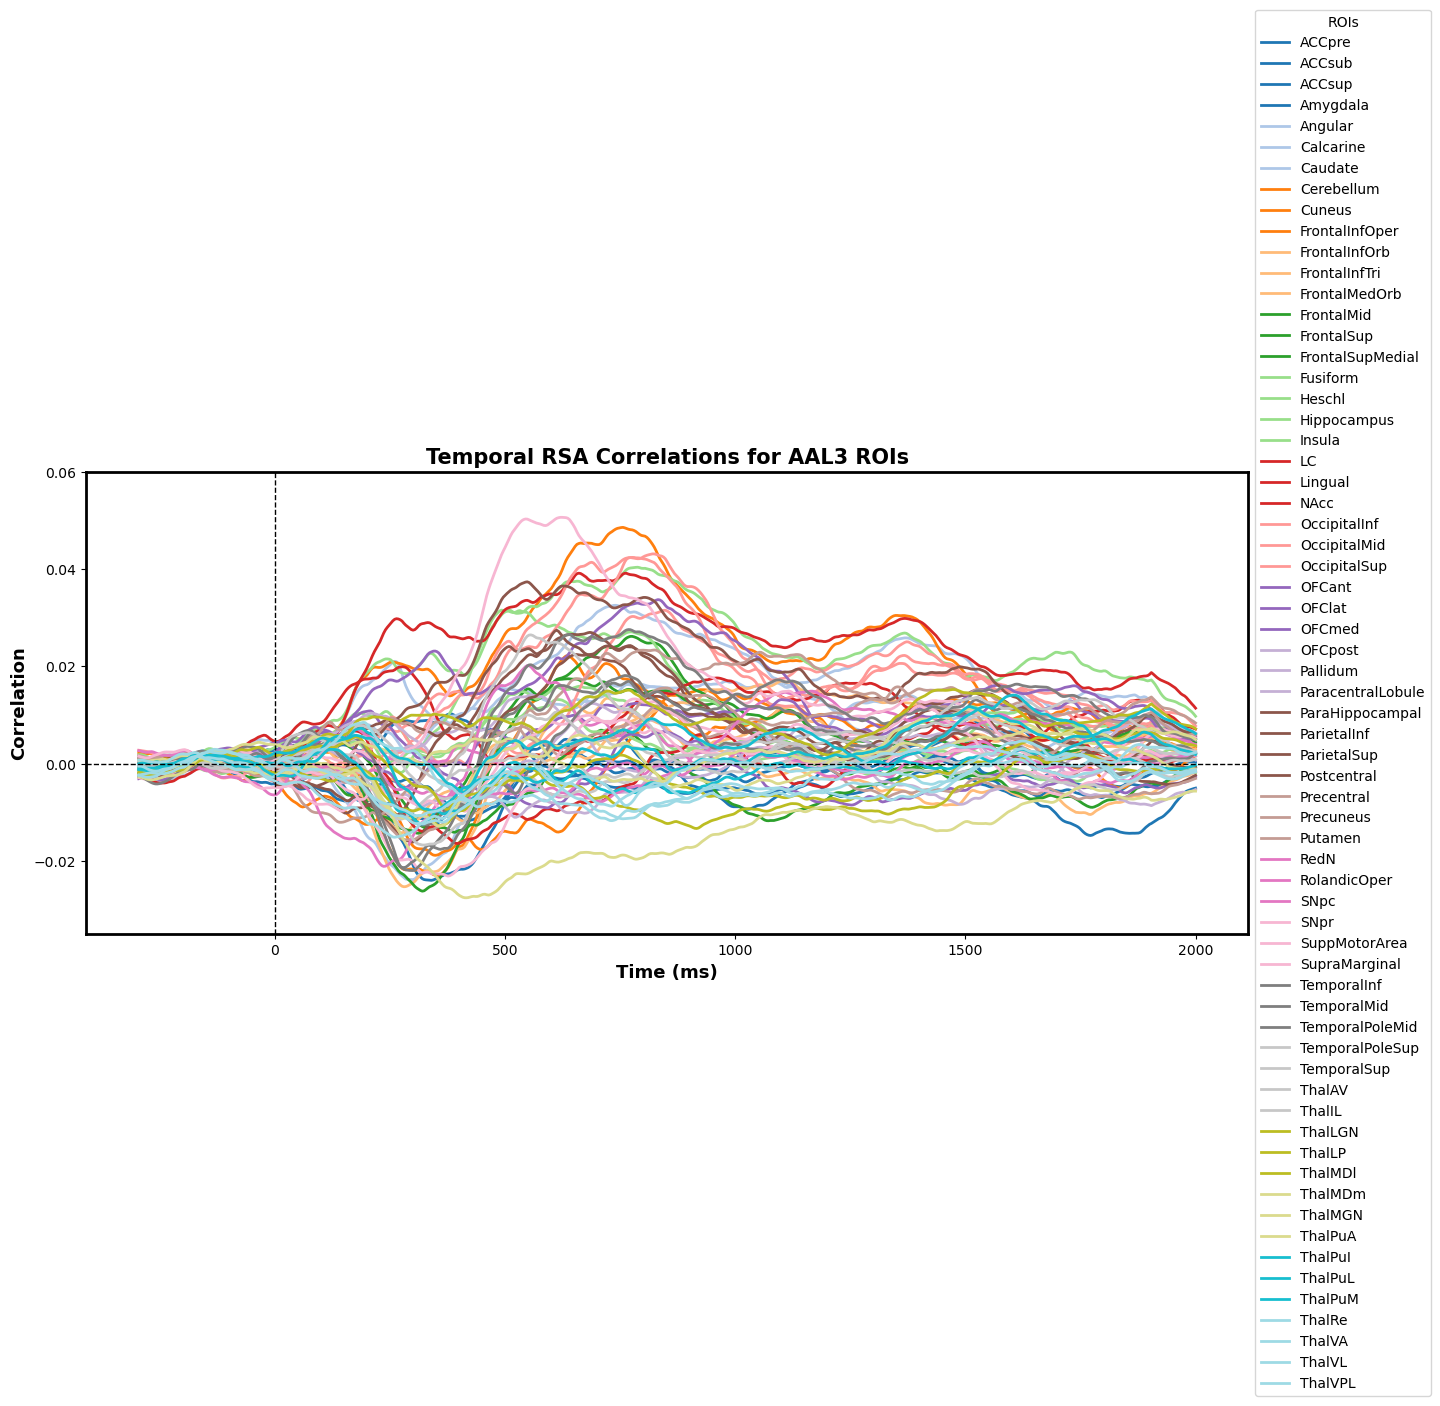

In [20]:
x = np.arange(1, 576) * 4 - 300  # Time axis: 1-575, multiplied by 4 and shifted by -300
zero_index = np.where(x >= 0)[0][0]
baseline_index = zero_index

plt.style.use('default')
fig, ax = plt.subplots(figsize=(15, 6))  # Increased width to accommodate legend
ax.set_ylim([-0.035, 0.06])
for spine in ax.spines.values():
    spine.set_linewidth(2)

def get_timecourse(rsa, baseline_data):
    """
    Computes a baseline-corrected and smoothed timecourse from RSA data,
    and finds the significant cluster indices.
    
    Parameters:
        rsa (numpy array): RSA correlations (e.g., shape (20,575))
        baseline_data (numpy array): RSA data used to compute the baseline, same shape as rsa.
        
    Returns:
        tc (numpy array): The processed timecourse.
        sig_idxs (numpy array): Array of significant indices.
        first (int or None): First significant index (or None if none found).
    """
    mean_baseline = np.mean(baseline_data[:, :baseline_index], axis=0)
    base_mean = mean_baseline.mean()
    base_std = mean_baseline.std()
    
    mean_tc = rsa.mean(axis=0)
    correction = mean_tc[:baseline_index].mean()
    tc = smooth(mean_tc - correction)
    
    sig_idxs = find_significant_clusters(tc, base_mean, base_std)
    if len(sig_idxs):
        first = sig_idxs[0]
        sig_idxs = np.arange(first, len(tc))
    else:
        first = None
    return tc, sig_idxs, first

timecourses = {}
for roi_name, rsa in aal3_rsa_dict.items():
    tc, sig, first = get_timecourse(rsa, rsa)
    timecourses[roi_name] = (tc, sig, first)
    # Uncomment the next line for diagnostic print-out:
    # print(f"{roi_name}: timecourse computed.")


# Create a color map with as many colors as there are ROIs.
num_rois = len(timecourses)
colors = plt.cm.tab20(np.linspace(0, 1, num_rois))

def plot_tc(tc, label, color):
    """
    Plots a timecourse without significance markers.
    
    Parameters:
        tc (numpy array): Processed timecourse.
        label (str): Label for the legend.
        color (str/array): Color for the line.
    """
    ax.plot(x, tc, label=label, color=color, linewidth=2)

# Loop through each ROI and plot its timecourse
for i, (roi_name, (tc, sig, first)) in enumerate(timecourses.items()):
    plot_tc(tc, roi_name, colors[i])

ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Time (ms)', fontsize=13, fontweight='bold')
ax.set_ylabel('Correlation', fontsize=13, fontweight='bold')
ax.set_title('Temporal RSA Correlations for AAL3 ROIs', fontsize=15, fontweight='bold')
ax.tick_params(axis='both', labelsize=10)

# Place the legend to the right of the plot
plt.legend(
    loc='center left', 
    bbox_to_anchor=(1, 0.5),  # Position legend to the right of the plot
    title='ROIs',
    ncol=1,            # Single column for better readability
    fontsize=10
)

# Adjust layout to make room for the legend
plt.tight_layout()
plt.show()

In [21]:
rows = []

# First row = “ROI” label + time axis values
rows.append(['ROI'] + x.tolist())

# One row per ROI
for roi_name, (tc, sig, first) in timecourses.items():
    rows.append([roi_name] + tc.tolist())

# Dump to CSV without header or index
output_csv = "adjusted_timecourses.csv"
pd.DataFrame(rows).to_csv(output_csv, index=False, header=False)